=== Scenario 5: SMOTE ===
Class Distribution Before SMOTE:
Fraud
0    110
1     10
Name: count, dtype: int64
\nClassification Report (Before SMOTE):
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        34
           1       0.00      0.00      0.00         2

    accuracy                           0.94        36
   macro avg       0.47      0.50      0.49        36
weighted avg       0.89      0.94      0.92        36

\nClass Distribution After SMOTE (Train Set):
Fraud
0    76
1    76
Name: count, dtype: int64
\nClassification Report (After SMOTE):
              precision    recall  f1-score   support

           0       0.97      0.82      0.89        34
           1       0.14      0.50      0.22         2

    accuracy                           0.81        36
   macro avg       0.55      0.66      0.56        36
weighted avg       0.92      0.81      0.85        36



/Users/manojmj/PycharmProjects/machinelearning subject/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/manojmj/PycharmProjects/machinelearning subject/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/manojmj/PycharmProjects/machinelearning subject/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

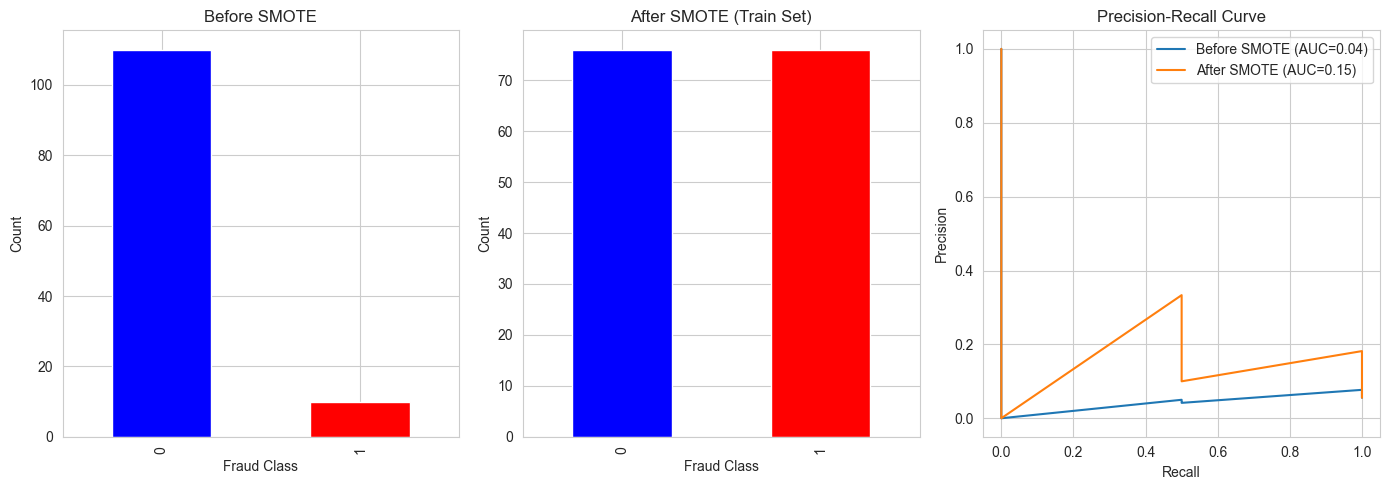

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc

def main():
    # Load Data
    df = pd.read_csv('../dataset/fraud_smote.csv')

    # Check imbalance
    class_counts_before = df['Fraud'].value_counts()
    print("=== Scenario 5: SMOTE ===")
    print("Class Distribution Before SMOTE:")
    print(class_counts_before)

    X = df.drop('Fraud', axis=1)
    y = df['Fraud']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Train without SMOTE
    rf_before = RandomForestClassifier(random_state=42)
    rf_before.fit(X_train, y_train)
    pred_before = rf_before.predict(X_test)
    probs_before = rf_before.predict_proba(X_test)[:, 1]

    print("\\nClassification Report (Before SMOTE):")
    print(classification_report(y_test, pred_before))

    # Apply SMOTE
    smote = SMOTE(random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

    # Check imbalance after SMOTE
    class_counts_after = pd.Series(y_train_sm).value_counts()
    print("\\nClass Distribution After SMOTE (Train Set):")
    print(class_counts_after)

    # Train with SMOTE
    rf_after = RandomForestClassifier(random_state=42)
    rf_after.fit(X_train_sm, y_train_sm)
    pred_after = rf_after.predict(X_test)
    probs_after = rf_after.predict_proba(X_test)[:, 1]

    print("\\nClassification Report (After SMOTE):")
    print(classification_report(y_test, pred_after))

    # Visualization
    plt.figure(figsize=(14, 5))

    # Class Distribution Before SMOTE
    plt.subplot(1, 3, 1)
    class_counts_before.plot(kind='bar', color=['blue', 'red'])
    plt.title('Before SMOTE')
    plt.xlabel('Fraud Class')
    plt.ylabel('Count')

    # Class Distribution After SMOTE
    plt.subplot(1, 3, 2)
    class_counts_after.plot(kind='bar', color=['blue', 'red'])
    plt.title('After SMOTE (Train Set)')
    plt.xlabel('Fraud Class')
    plt.ylabel('Count')

    # Precision-Recall Curve
    plt.subplot(1, 3, 3)
    p_b, r_b, _ = precision_recall_curve(y_test, probs_before)
    p_a, r_a, _ = precision_recall_curve(y_test, probs_after)

    plt.plot(r_b, p_b, label=f'Before SMOTE (AUC={auc(r_b, p_b):.2f})')
    plt.plot(r_a, p_a, label=f'After SMOTE (AUC={auc(r_a, p_a):.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()
